In [1]:
import scanpy as sc
import scvi
import seaborn as sns
import pandas as pd
import numpy as np
#!pip install plotly
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
import scvelo as scv

In [2]:
name='1month'
adata = sc.read_h5ad(f'/python/Results_ann/expr_{name}_annotated.h5ad')
adata

AnnData object with n_obs × n_vars = 64109 × 1363
    obs: 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'leiden', 'paper_annotation', 'annot_level_1', 'annot_level_2', 'annot_level_3_rev2', 'annot_level_4_rev2', 'cell_type'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'rep'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

## 1

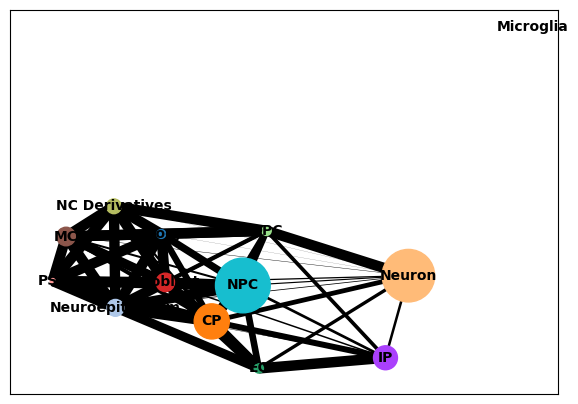

In [4]:
annotation_level='annot_level_1'
sc.tl.paga(adata, groups=annotation_level)

# Visualize the PAGA graph
sc.pl.paga(adata, color=annotation_level)

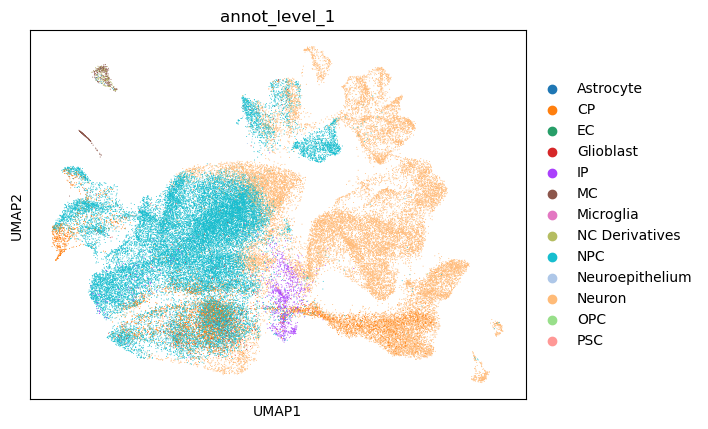

In [5]:
sc.tl.umap(adata, init_pos='paga')
sc.pl.umap(adata, color=annotation_level)

## 2

In [61]:
annotation_level='annot_level_2'
cell_type_list=adata.obs[annotation_level].unique()
for i in sorted(cell_type_list):
    print(i)

Astrocyte
CP
Dorsal Telencephalic IP
Dorsal Telencephalic NPC
Dorsal Telencephalic Neuron
EC
Glioblast
MC
NC Derivatives
Neuroepithelium
Non-telencephalic NPC
Non-telencephalic Neuron
OPC
PSC
Ventral Telencephalic NPC
Ventral Telencephalic Neuron


In [62]:
root_cell_type = 'Neuroepithelium'
adata.uns['iroot'] = np.flatnonzero(adata.obs[annotation_level] == root_cell_type)[0]

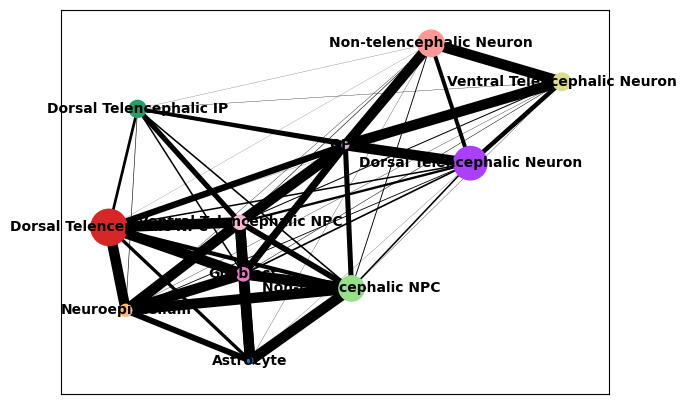

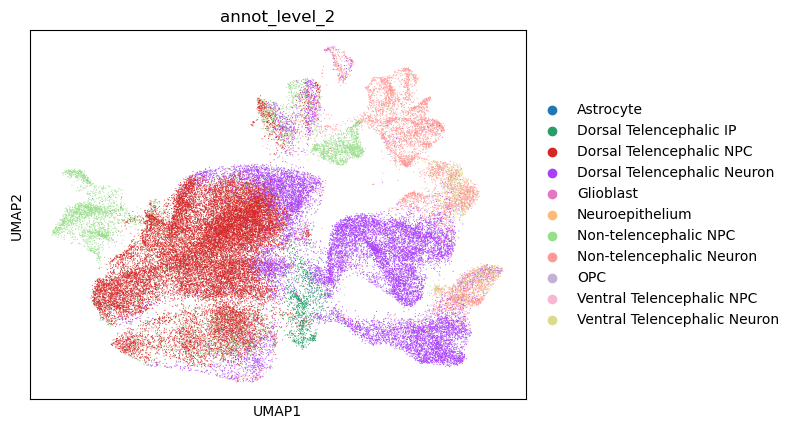

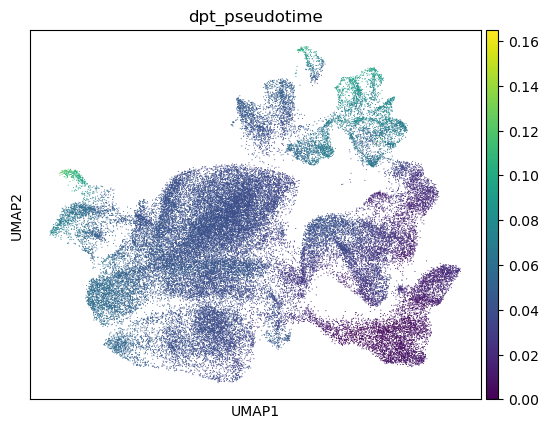

In [69]:
# List the exact cell types you want to exclude
cells_to_remove = ['EC', 'MC', 'NC Derivatives', 'CP', 'PSC']
clusters_to_remove = ['26', '27', '28', '29', '30']

# Subset the anndata object
mask = (~adata.obs[annotation_level].isin(cells_to_remove)) & (~adata.obs['leiden'].isin(clusters_to_remove))
adata_neural = adata[mask].copy()

sc.tl.paga(adata_neural, groups=annotation_level)
sc.pl.paga(adata_neural, color=annotation_level, save='_attempt_pseudotyme.png')

# for i in sorted(adata_neural.obs[annotation_level].unique()):
#     print(i)

# Recalculate PCA, Neighbors, and Diffusion Map on the cleaned dataset
sc.pp.pca(adata_neural)
sc.pp.neighbors(adata_neural)
sc.tl.diffmap(adata_neural)

sc.pl.umap(adata_neural, color=annotation_level)
sc.pl.umap(adata_neural, color='dpt_pseudotime', save='_attempt_pseudotyme.png')

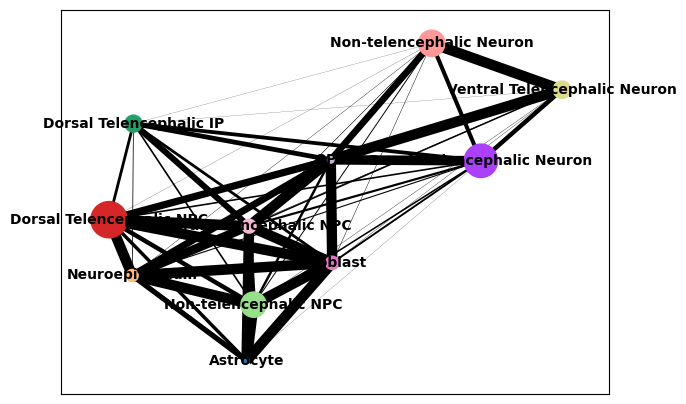

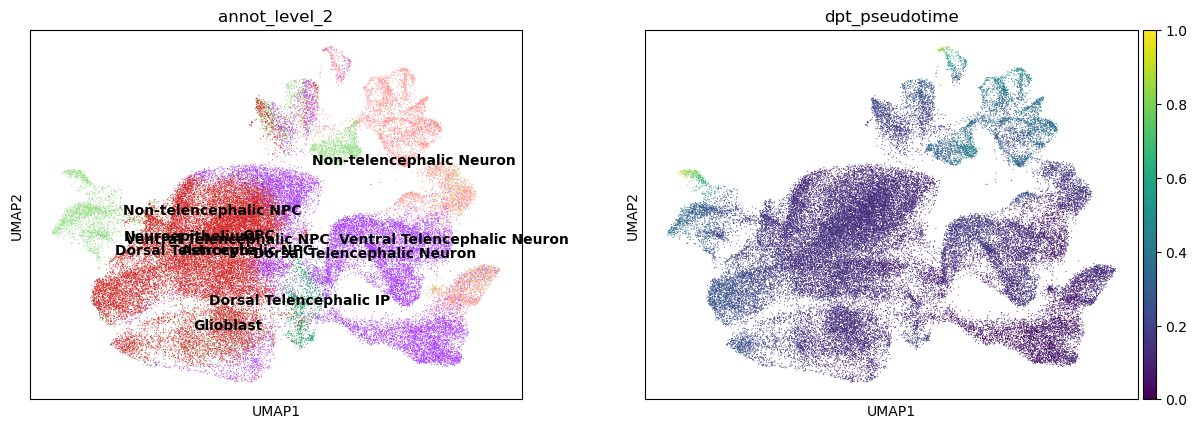

In [70]:
# 1. Combine conditions to subset correctly
cells_to_remove = ['EC', 'MC', 'NC Derivatives', 'CP', 'PSC']
clusters_to_remove = ['26', '27', '28', '29', '30']
mask = (~adata.obs[annotation_level].isin(cells_to_remove)) & (~adata.obs['leiden'].isin(clusters_to_remove))
adata_neural = adata[mask].copy()

# 2. Recalculate PCA and Neighbors FIRST
sc.pp.pca(adata_neural)
sc.pp.neighbors(adata_neural)

# 3. Run PAGA on the clean graph
sc.tl.paga(adata_neural, groups=annotation_level)
sc.pl.paga(adata_neural, color=annotation_level, save='_cleaned_paga.png')

# 4. Run Diffusion Map
sc.tl.diffmap(adata_neural)

# 5. Set the root and calculate DPT
root_cell_type = 'Neuroepithelium'
adata_neural.uns['iroot'] = np.flatnonzero(adata_neural.obs[annotation_level] == root_cell_type)[0]
sc.tl.dpt(adata_neural)

# 6. Plot
sc.pl.umap(adata_neural, color=[annotation_level, 'dpt_pseudotime'], save='_cleaned_pseudotime.png')

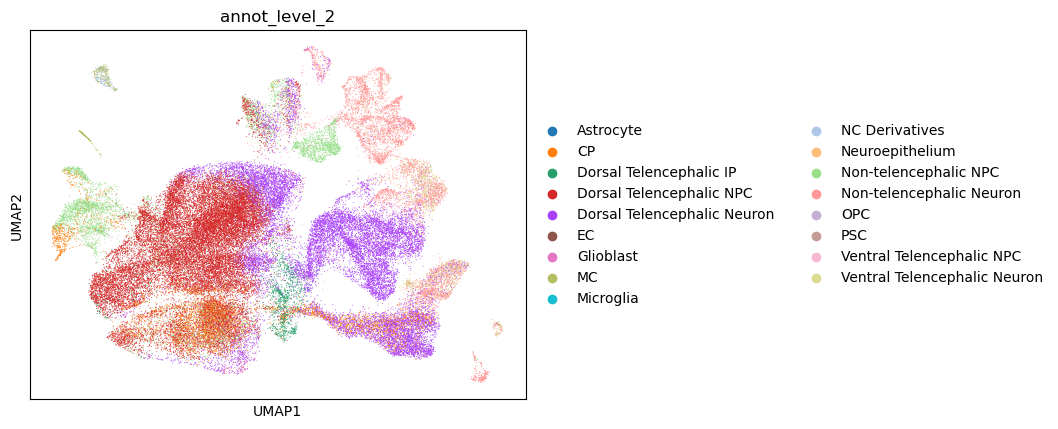

In [38]:
sc.pl.umap(adata, color=[annotation_level])

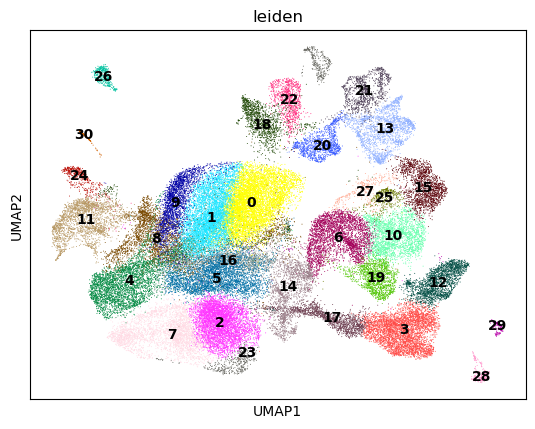

In [49]:
sc.pl.umap(adata, color='leiden', legend_loc='on data' )

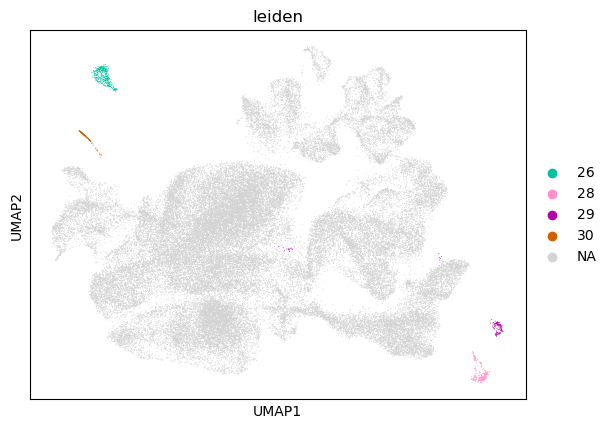

In [50]:
sc.pl.umap(adata, color='leiden', groups=['26', '30', '28', '29'])